<a href="https://colab.research.google.com/github/Rathinagrace/R_Portfolio/blob/master/simple_implementing_cnn_in_r_programming_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Network (CNN) in R Programming
> This tutorial demonstrates training a simple Convolutional Neural Network (CNN) to classify CIFAR images. Because this tutorial uses the Keras Sequential API, creating and training our model will take just a few lines of code.

![](https://miro.medium.com/max/2000/1*vkQ0hXDaQv57sALXAJquxA.jpeg)

## Library required are:

In [ ]:
system('sudo apt-get update')
system('sudo apt-get install -y python3-venv python3-pip python3-dev')
install.packages("tensorflow")
tensorflow::install_tensorflow()
install.packages("keras")
keras::install_keras()

library(tensorflow)
library(keras)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’, ‘config’, ‘reticulate’, ‘tfruns’, ‘tfautograph’




Using Python: /usr/bin/python3.10
Creating virtual environment 'r-tensorflow' ... 


+ /usr/bin/python3.10 -m venv /root/.virtualenvs/r-tensorflow



Done!
Installing packages: pip, wheel, setuptools


+ /root/.virtualenvs/r-tensorflow/bin/python -m pip install --upgrade pip wheel setuptools



...

+ /root/.virtualenvs/r-tensorflow/bin/python -m pip install --upgrade pip wheel setuptools



Virtual environment 'r-tensorflow' successfully created.
Using virtual environment 'r-tensorflow' ...


+ /root/.virtualenvs/r-tensorflow/bin/python -m pip install --upgrade --no-user 'numpy<2' 'tensorflow==2.15.*' tensorflow-hub tensorflow-datasets scipy requests Pillow h5py pandas pydot tf-keras




Installation complete.



The keras package is deprecated. Please use the keras3 package instead.
Alternatively, to continue using legacy keras, call `py_require_legacy_keras()`.



## Loading Dataset
> #### About dataset:
> ##### The CIFAR10 dataset contains 60,000 color images in 10 classes, with 6,000 images in each class.
> ##### The dataset is divided into 50,000 training images and 10,000 testing images.
> ##### The classes are mutually exclusive and there is no overlap between them.

In [ ]:
cifar <- dataset_cifar10()

## Verify the data
> #### To verify that the dataset looks correct, let’s plot the first 25 images from the training set and display the class name below each image.

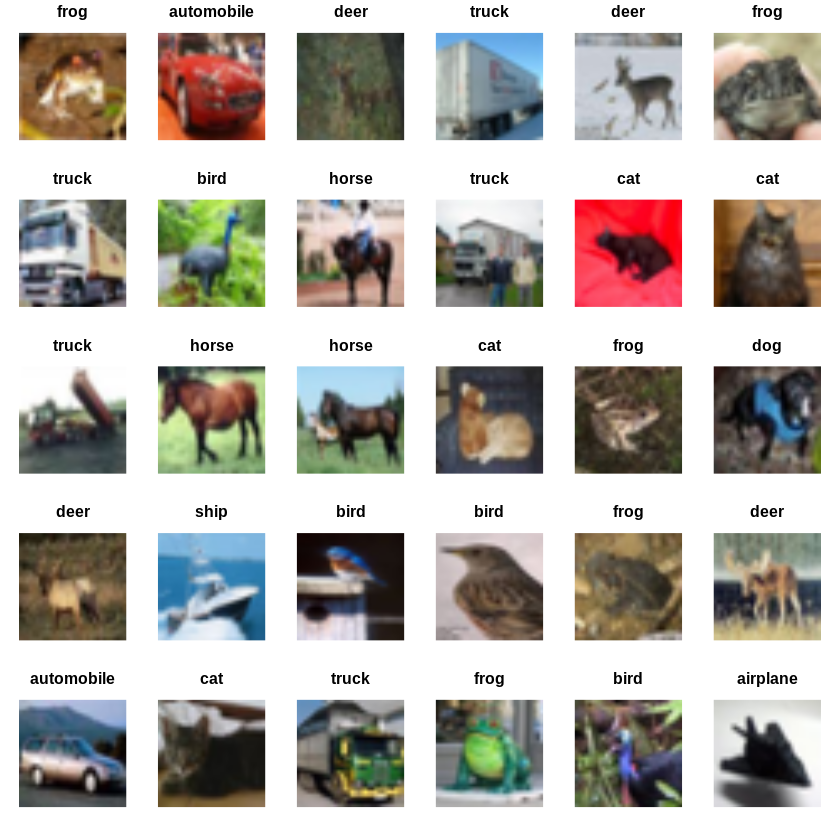

In [ ]:
class_names <- c('airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck')

index <- 1:30

par(mfcol = c(5,6), mar = rep(1, 4), oma = rep(0.2, 4))
cifar$train$x[index,,,] %>%
  purrr::array_tree(1) %>%
  purrr::set_names(class_names[cifar$train$y[index] + 1]) %>%
  purrr::map(as.raster, max = 255) %>%
  purrr::iwalk(~{plot(.x); title(.y)})

## Create the convolutional base
> #### The 6 lines of code below define the convolutional base using a common pattern: a stack of Conv2D and MaxPooling2D layers.
> #### As input, a CNN takes tensors of shape (image_height, image_width, color_channels), ignoring the batch size. If you are new to these dimensions, color_channels refers to (R,G,B). In this example, you will configure our CNN to process inputs of shape (32, 32, 3), which is the format of CIFAR images. You can do this by passing the argument input_shape to our first layer.

In [ ]:
model <- keras_model_sequential() %>%
  layer_conv_2d(filters = 32, kernel_size = c(3,3), activation = "relu",
                input_shape = c(32,32,3)) %>%
  layer_max_pooling_2d(pool_size = c(2,2)) %>%
  layer_conv_2d(filters = 64, kernel_size = c(3,3), activation = "relu") %>%
  layer_max_pooling_2d(pool_size = c(2,2)) %>%
  layer_conv_2d(filters = 64, kernel_size = c(3,3), activation = "relu")

### Let’s display the architecture of our model so far.

In [ ]:
summary(model)

Model: "sequential"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 conv2d_2 (Conv2D)                  (None, 30, 30, 32)              896         
 max_pooling2d_1 (MaxPooling2D)     (None, 15, 15, 32)              0           
 conv2d_1 (Conv2D)                  (None, 13, 13, 64)              18496       
 max_pooling2d (MaxPooling2D)       (None, 6, 6, 64)                0           
 conv2d (Conv2D)                    (None, 4, 4, 64)                36928       
Total params: 56320 (220.00 KB)
Trainable params: 56320 (220.00 KB)
Non-trainable params: 0 (0.00 Byte)
________________________________________________________________________________


####  Above, you can see that the output of every Conv2D and MaxPooling2D layer is a 3D tensor of shape (height, width, channels). The width and height dimensions tend to shrink as you go deeper in the network. The number of output channels for each Conv2D layer is controlled by the first argument (e.g., 32 or 64). Typically, as the width and height shrink, you can afford (computationally) to add more output channels in each Conv2D layer.

## Add Dense layers on top
#### To complete our model, you will feed the last output tensor from the convolutional base (of shape (3, 3, 64)) into one or more Dense layers to perform classification. Dense layers take vectors as input (which are 1D), while the current output is a 3D tensor. First, you will flatten (or unroll) the 3D output to 1D, then add one or more Dense layers on top. CIFAR has 10 output classes, so you use a final Dense layer with 10 outputs and a softmax activation.

In [ ]:
model %>%
  layer_flatten() %>%
  layer_dense(units = 64, activation = "relu") %>%
  layer_dense(units = 10, activation = "softmax")

#### Here’s the complete architecture of our model.

#### **Note**: Keras models are mutable objects and you don’t need to re-assign model in the chubnk above.

In [ ]:
summary(model)

Model: "sequential"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 conv2d_2 (Conv2D)                  (None, 30, 30, 32)              896         
 max_pooling2d_1 (MaxPooling2D)     (None, 15, 15, 32)              0           
 conv2d_1 (Conv2D)                  (None, 13, 13, 64)              18496       
 max_pooling2d (MaxPooling2D)       (None, 6, 6, 64)                0           
 conv2d (Conv2D)                    (None, 4, 4, 64)                36928       
 flatten (Flatten)                  (None, 1024)                    0           
 dense_1 (Dense)                    (None, 64)                      65600       
 dense (Dense)                      (None, 10)                      650         
Total params: 122570 (478.79 KB)
Trainable params: 122570 (478.79 KB)
Non-trainable params: 0 (0.00 Byte)
________________________________________________________________

#### As you can see, our (3, 3, 64) outputs were flattened into vectors of shape (576) before going through two Dense layers.

## Compile and train the model

In [ ]:
model %>% compile(
  optimizer = "adam",
  loss = "sparse_categorical_crossentropy",
  metrics = "accuracy"
)

In [ ]:
history <- model %>%
  fit(
    x = cifar$train$x, y = cifar$train$y,
    epochs = 10,
    validation_data = unname(cifar$test),
    verbose = 2
  )

##### Train on 50000 samples, validate on 10000 samples
##### Epoch 1/10
##### 50000/50000 - 33s - loss: 1.8909 - accuracy: 0.3912 - val_loss: 1.4419 - val_accuracy: 0.4769
##### Epoch 2/10
##### 50000/50000 - 31s - loss: 1.3519 - accuracy: 0.5165 - val_loss: 1.3589 - val_accuracy: 0.5253
##### Epoch 3/10
##### 50000/50000 - 32s - loss: 1.1962 - accuracy: 0.5797 - val_loss: 1.1695 - val_accuracy: 0.5867
##### Epoch 4/10
##### 50000/50000 - 34s - loss: 1.0811 - accuracy: 0.6243 - val_loss: 1.1108 - val_accuracy: 0.6217
##### Epoch 5/10
##### 50000/50000 - 34s - loss: 1.0010 - accuracy: 0.6516 - val_loss: 1.0483 - val_accuracy: 0.6463
##### Epoch 6/10
##### 50000/50000 - 33s - loss: 0.9441 - accuracy: 0.6725 - val_loss: 1.0655 - val_accuracy: 0.6376
##### Epoch 7/10
##### 50000/50000 - 33s - loss: 0.8754 - accuracy: 0.6966 - val_loss: 1.0486 - val_accuracy: 0.6528
##### Epoch 8/10
##### 50000/50000 - 33s - loss: 0.8300 - accuracy: 0.7127 - val_loss: 1.1089 - val_accuracy: 0.6313
##### Epoch 9/10
##### 50000/50000 - 33s - loss: 0.7887 - accuracy: 0.7246 - val_loss: 1.0807 - val_accuracy: 0.6439
##### Epoch 10/10
##### 50000/50000 - 34s - loss: 0.7503 - accuracy: 0.7398 - val_loss: 1.0982 - val_accuracy: 0.6576

In [ ]:
print(history)


Final epoch (plot to see history):
        loss: 0.7184
    accuracy: 0.7534
    val_loss: 1.013
val_accuracy: 0.6766 


## Evaluate the model

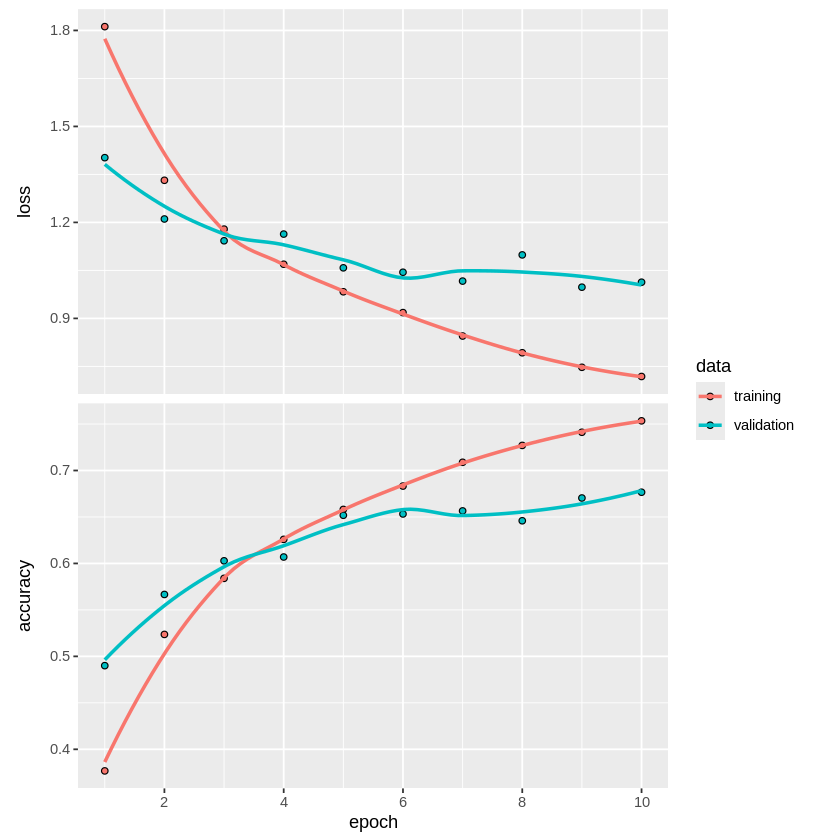

In [ ]:
plot(history)

In [ ]:
evaluate(model, cifar$test$x, cifar$test$y, verbose = 0)

loss accuracy 
1.013088 0.676600

Our simple CNN has achieved a test accuracy of over 65%. Not bad for a few lines of code!

### References:

- [Tensorflow for R](https://tensorflow.rstudio.com/tutorials/advanced/images/cnn/)

- [Towards Data Science](https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53)